In [25]:
# 1. Imports
import os
import json
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, ParameterGrid
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Create cache directory
os.makedirs('./GBM_cache', exist_ok=True)

# 3. Load & prepare data
df = pd.read_csv('../data/train.csv')
X = df.drop('response', axis=1).values
y = df['response'].map({1: 0, 2: 1}).values  # 0=non-spam, 1=spam

# 4. Define custom cost function
def compute_cost(y_true, p_spam, thresh):
    preds = (p_spam >= thresh).astype(int)
    fp = ((preds == 1) & (y_true == 0)).sum()
    fn = ((preds == 0) & (y_true == 1)).sum()
    return (5 * fp + 1 * fn) / len(y_true)

# 5. CV and threshold setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
thresholds = np.linspace(0, 1, 101)

# 6. Define XGBoost parameter grid
param_grid = {
    'n_estimators': [300, 500],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}
grid = list(ParameterGrid(param_grid))

# 7. Helper to create cache filename
def params_to_filename(params):
    return './GBM_cache/' + '_'.join([f"{k}-{v}" for k, v in params.items()]) + '.json'

# 8. Manual grid search with caching
results = []
for params in tqdm(grid, desc="XGB Hyperparam tuning"):
    cache_file = params_to_filename(params)
    
    if os.path.exists(cache_file):
        # Load from cache
        with open(cache_file, 'r') as f:
            cached_result = json.load(f)
        avg_cost = cached_result['avg_cost']
        best_thresh = cached_result['best_thresh']
    else:
        # Compute normally
        oof_preds = np.zeros_like(y, dtype=float)  # store out-of-fold spam probabilities
        
        for train_idx, val_idx in cv.split(X, y):
            X_tr, X_val = X[train_idx], X[val_idx]
            y_tr, y_val = y[train_idx], y[val_idx]
            
            model = XGBClassifier(**params, random_state=42, n_jobs=-1, eval_metric='logloss')
            model.fit(X_tr, y_tr)
            oof_preds[val_idx] = model.predict_proba(X_val)[:, 1]

        costs = [compute_cost(y, oof_preds, t) for t in thresholds]
        best_idx = np.argmin(costs)
        best_thresh = thresholds[best_idx]
        avg_cost = costs[best_idx]

        # Save result to cache
        with open(cache_file, 'w') as f:
            json.dump({'avg_cost': avg_cost, 'best_thresh': best_thresh}, f)

    results.append({**params, 'avg_cost': avg_cost, 'best_thresh': best_thresh})

# 9. Summarize results
results_df = pd.DataFrame(results).sort_values('avg_cost').reset_index(drop=True)
print("\nTop 5 hyperparameter settings by CV-estimated cost:")
print(results_df.head(5))

best_params = results_df.loc[0, list(param_grid.keys())].to_dict()
best_threshold = results_df.loc[0, 'best_thresh']
print(f"\nBest params: {best_params}")
print(f"Best CV-estimated cost: {results_df.loc[0,'avg_cost']:.4f}")
print(f"Best threshold: {best_threshold:.2f}")


XGB Hyperparam tuning: 100%|██████████| 162/162 [18:34<00:00,  6.88s/it]


Top 5 hyperparameter settings by CV-estimated cost:
   colsample_bytree  learning_rate  max_depth  n_estimators  subsample  \
0               1.0           0.05          8           500        0.8   
1               1.0           0.05          8           300        0.7   
2               1.0           0.05          8           300        0.8   
3               1.0           0.10          8           300        0.8   
4               1.0           0.10          6           300        0.8   

   avg_cost  best_thresh  
0  0.075782         0.84  
1  0.076104         0.84  
2  0.077072         0.83  
3  0.077072         0.86  
4  0.077717         0.87  

Best params: {'n_estimators': 500.0, 'max_depth': 8.0, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 1.0}
Best CV-estimated cost: 0.0758
Best threshold: 0.84


Optimal threshold = 0.88, CV cost = 0.0832


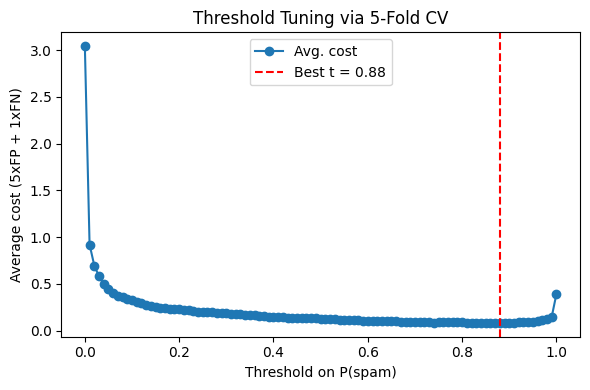


5-Fold CV Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.99      0.95      1886
           1       0.98      0.87      0.92      1215

    accuracy                           0.94      3101
   macro avg       0.95      0.93      0.94      3101
weighted avg       0.94      0.94      0.94      3101



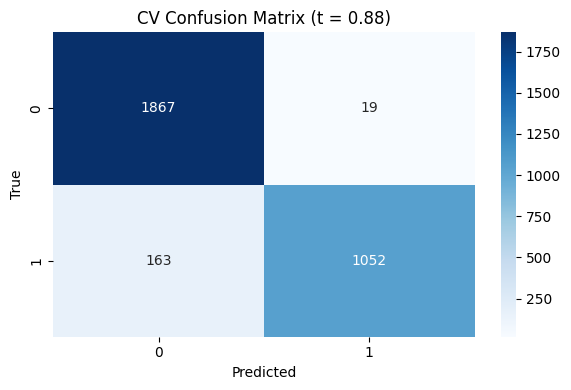


Predictions saved to '../prediction/predicted_GBM.txt'.


In [27]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load & Prepare the Data
filtered_train_df = pd.read_csv('../data/train.csv')
X = filtered_train_df.drop('response', axis=1)
y = filtered_train_df['response'].map({1: 0, 2: 1})

best_est = 500
best_depth = 6
best_learn = 0.05
best_sub = 0.8
best_bytree = 0.8

# best_est = 500
# best_depth = 8
# best_learn = 0.05
# best_sub = 0.8
# best_bytree = 1

# 2. Set up 5-Fold CV and initial GBM model
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
gbm = XGBClassifier(
    n_estimators=best_est,
    max_depth=best_depth,
    learning_rate=best_learn,
    subsample=best_sub,
    colsample_bytree=best_bytree,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'  # <-- keep this
)

# 3. Obtain out-of-fold spam probabilities
p_spam_oof = cross_val_predict(
    gbm, X, y,
    cv=cv,
    method='predict_proba'
)[:, 1]

# 4. Tune Decision Threshold on OOF predictions
def compute_cost(y_true, p_spam, thresh):
    preds = (p_spam >= thresh).astype(int)
    fp = ((preds == 1) & (y_true == 0)).sum()
    fn = ((preds == 0) & (y_true == 1)).sum()
    return (5 * fp + 1 * fn) / len(y_true)

thresholds = np.linspace(0, 1, 101)
costs = [compute_cost(y.values, p_spam_oof, t) for t in thresholds]
best_idx = np.argmin(costs)
best_thresh = thresholds[best_idx]
print(f"Optimal threshold = {best_thresh:.2f}, CV cost = {costs[best_idx]:.4f}")

# 5. Visualize cost vs. threshold
plt.figure(figsize=(6,4))
plt.plot(thresholds, costs, marker='o', label='Avg. cost')
plt.axvline(best_thresh, color='red', linestyle='--', label=f"Best t = {best_thresh:.2f}")
plt.xlabel("Threshold on P(spam)")
plt.ylabel("Average cost (5xFP + 1xFN)")
plt.title("Threshold Tuning via 5-Fold CV")
plt.legend()
plt.tight_layout()
plt.show()

# 6. Evaluate OOF performance at best_thresh
y_oof_pred = (p_spam_oof >= best_thresh).astype(int)
print("\n5-Fold CV Classification Report:")
print(classification_report(y, y_oof_pred))

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y, y_oof_pred), annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"CV Confusion Matrix (t = {best_thresh:.2f})")
plt.tight_layout()
plt.show()

# 7. Retrain on Full Labeled Data
gbm_full = XGBClassifier(
    n_estimators=best_est,
    max_depth=best_depth,
    learning_rate=best_learn,
    subsample=best_sub,
    colsample_bytree=best_bytree,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)
gbm_full.fit(X, y)

# 8. Predict on Unlabeled Test Data
test_df = pd.read_csv('../data/test.csv')
p_spam_test = gbm_full.predict_proba(test_df)[:, 1]
y_pred_test = (p_spam_test >= best_thresh).astype(int)

# Map back to original labels {1: non-spam, 2: spam}
response_pred = pd.Series(y_pred_test).map({0: 1, 1: 2})

# 9. Save Final Predictions
response_pred.to_csv(
    '../prediction/predicted_GBM.txt',
    sep='\t',
    index=False,
    header=False
)
print("\nPredictions saved to '../prediction/predicted_GBM.txt'.")
